# <font color='dark'>**Classificação: Validação de modelos e métricas de avaliação**</h1>

### Projeto

Uma empresa de empréstimo de automóveis está passando por uma situação complicada, com alta demanda para uma frota reduzida de veículos e alto número de inadimplentes, trazendo um prejuízo grande para a empresa.

Nós fomos contratados para buscar melhorias na identificação de inadimplentes. A análise dos clientes atualmente é feita de forma manual, cliente por cliente, tomando muito tempo e ainda assim a detecção de inadimplentes é muito imprecisa.

Nossa tarefa é utilizar os dados fornecidos pela empresa para **classificar** os clientes em adimplentes e inadimplentes.

## <font color='dark'>Classificando dados</h1>

### Criando um modelo inicial

In [4]:
import pandas as pd

In [ ]:
dados = pd.read_csv("Dados/emp_automovel.csv")

In [6]:
dados.head()

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.0,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.0,0
1,9000.0,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.0,0
2,15750.0,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.0,0
3,9000.0,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.0,0
4,7650.0,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.0,0


In [7]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54025 entries, 0 to 54024
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      54025 non-null  float64
 1   anuidade_emprestimo  54025 non-null  float64
 2   anos_casa_propria    54025 non-null  float64
 3   telefone_trab        54025 non-null  int64  
 4   avaliacao_cidade     54025 non-null  float64
 5   score_1              54025 non-null  float64
 6   score_2              54025 non-null  float64
 7   score_3              54025 non-null  float64
 8   score_social         54025 non-null  float64
 9   troca_telefone       54025 non-null  float64
 10  inadimplente         54025 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


In [8]:
X = dados.drop("inadimplente", axis=1)
y = dados.inadimplente

In [9]:
from sklearn.tree import DecisionTreeClassifier

In [10]:
modelo = DecisionTreeClassifier()
modelo.fit(X, y)

DecisionTreeClassifier()

In [11]:
modelo.score(X,y)

1.0

In [12]:
print(f"Acuracia: {modelo.score(X, y)}")

Acuracia: 1.0


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X, X_test, y, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=5)

In [15]:
X_train, X_val, y_train, y_val =train_test_split(X, y, stratify=y, random_state=5)

In [16]:
modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

DecisionTreeClassifier()

In [17]:
print(f"Acuracia de treino: {modelo.score(X_train, y_train)}")
print(f"Acuracia de validação: {modelo.score(X_val, y_val)}")

Acuracia de treino: 1.0
Acuracia de validação: 0.8488807595157216


In [18]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [19]:
print(f"Acuracia de treino: {modelo.score(X_train, y_train)}")
print(f"Acuracia de validação: {modelo.score(X_val, y_val)}")

Acuracia de treino: 0.9206445993031359
Acuracia de validação: 0.9055831373573731


### Avaliando o modelo

In [20]:
from sklearn.metrics import confusion_matrix

In [21]:
y_previsto = modelo.predict(X_val)

In [22]:
matriz_confusao = confusion_matrix(y_val, y_previsto)
print(matriz_confusao)

[[10354   125]
 [  959    43]]


In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

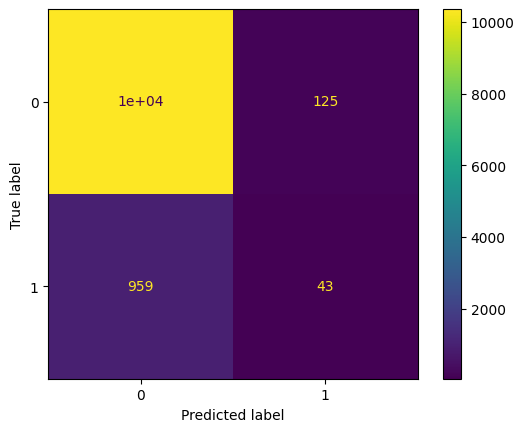

In [24]:
visualicao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualicao.plot();

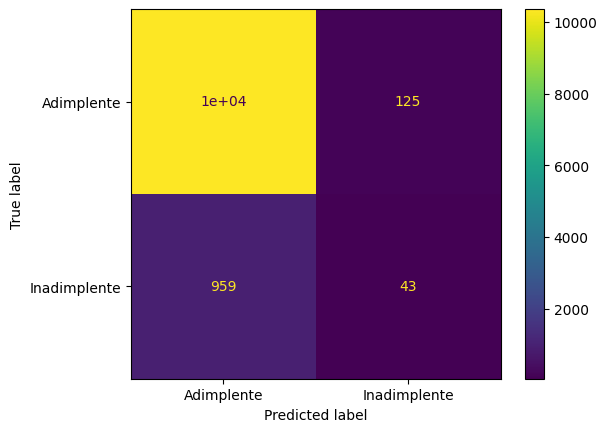

In [25]:
visualicao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=["Adimplente", "Inadimplente"])
visualicao.plot();

# Aula 2  - Metricas de Avalição

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
print(f"Accuracia: {accuracy_score(y_val, y_previsto)}")

Accuracia: 0.9055831373573731


In [28]:
from sklearn.metrics import precision_score, recall_score

In [29]:
print(f"Precisão: {precision_score(y_val, y_previsto)}")
print(f"Recall: {recall_score(y_val, y_previsto)}")


Precisão: 0.25595238095238093
Recall: 0.04291417165668663


In [30]:
from sklearn.metrics import f1_score

In [31]:
print(f"f1_score: {f1_score(y_val, y_previsto)}")

f1_score: 0.0735042735042735


#### Curva ROC

In [32]:
from sklearn.metrics import RocCurveDisplay

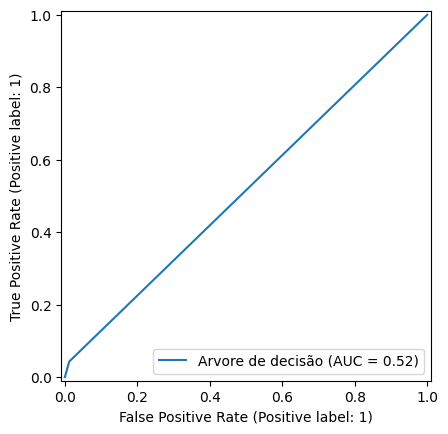

In [33]:
RocCurveDisplay.from_predictions(y_val, y_previsto, name="Arvore de decisão")

In [34]:
from sklearn.metrics import roc_auc_score

In [35]:
print(f"AUC: {roc_auc_score(y_val, y_previsto)}")

AUC: 0.5154927762568193


#### Curva de precisão x recall

In [36]:
from sklearn.metrics import PrecisionRecallDisplay

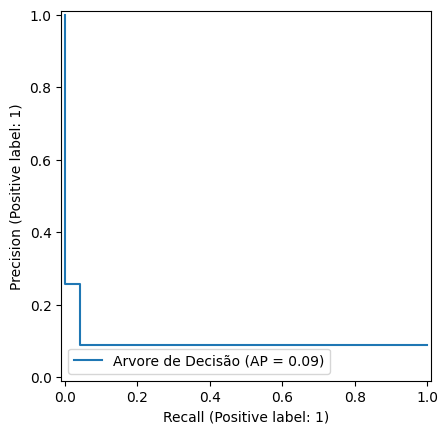

In [37]:
PrecisionRecallDisplay.from_predictions(y_val, y_previsto, name="Arvore de Decisão")

In [38]:
from sklearn.metrics import average_precision_score

In [39]:
print(f"AP: {average_precision_score(y_val, y_previsto)}")


AP: 0.09451329370574367


### Relatório de metricas

In [40]:
from sklearn.metrics import classification_report

In [41]:
print(classification_report(y_val, y_previsto))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.26      0.04      0.07      1002

    accuracy                           0.91     11481
   macro avg       0.59      0.52      0.51     11481
weighted avg       0.86      0.91      0.87     11481



#### Aula 3 - Validação Cruzada

In [42]:
from sklearn.model_selection import cross_validate, KFold

In [43]:
modelo = DecisionTreeClassifier(max_depth=10)

In [44]:
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, X, y, cv=kf)
cv_resultados

{'fit_time': array([0.18920636, 0.1810894 , 0.18132281, 0.19662666, 0.18310475]),
 'score_time': array([0.00347328, 0.00227618, 0.00228381, 0.00355268, 0.00234008]),
 'test_score': array([0.91366358, 0.90744774, 0.90744774, 0.91343641, 0.89960801])}

In [45]:
cv_resultados["test_score"]

array([0.91366358, 0.90744774, 0.90744774, 0.91343641, 0.89960801])

In [46]:
media = cv_resultados["test_score"].mean()
desvio = cv_resultados["test_score"].std()
print(f"O intervalo de confiança é [{media - 2 * desvio}, {min(media + 2 * desvio, 1)}]")

O intervalo de confiança é [0.8980385975847756, 0.9186027933741998]


#### Validação cruzada com recall

In [47]:
def intervalo_conf(resultados):
    media = resultados["test_score"].mean()
    desvio = resultados["test_score"].std()
    print(f"O intervalo de confiança é [{media - 2 * desvio}, {min(media + 2 * desvio, 1)}]")

In [48]:
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, X, y, cv=kf, scoring="recall")
cv_resultados

{'fit_time': array([0.18562603, 0.1825912 , 0.18375778, 0.18325019, 0.1977303 ]),
 'score_time': array([0.0043025 , 0.0041585 , 0.00400352, 0.00413275, 0.00395465]),
 'test_score': array([0.02642008, 0.01732673, 0.0196802 , 0.01436031, 0.02543353])}

In [49]:
intervalo_conf(cv_resultados)

O intervalo de confiança é [0.011361043054917048, 0.02992729617026724]


#### Estratificando os dados

In [50]:
dados["inadimplente"].value_counts(normalize=True)

,proportion
inadimplente,
0,0.912707
1,0.087293


In [51]:
from sklearn.model_selection import StratifiedKFold

In [52]:
modelo = DecisionTreeClassifier(max_depth = 10)
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, X, y, cv = skf, scoring='recall')


In [53]:
intervalo_conf(cv_resultados)

O intervalo de confiança é [0.016681652518596074, 0.037695513181386184]


### Balanceamento de Dados

In [54]:
from imblearn.over_sampling import SMOTE

In [55]:
oversample = SMOTE()
X_balanceado, y_balanceado = oversample.fit_resample(X, y)


In [56]:
y_balanceado.value_counts(normalize=True)

,proportion
inadimplente,
0,0.5
1,0.5


In [57]:
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, X_balanceado, y_balanceado, cv=kf, scoring="recall")
cv_resultados

{'fit_time': array([0.48279691, 0.40191841, 0.38070679, 0.39349747, 0.39863372]),
 'score_time': array([0.0051651 , 0.00517297, 0.00523543, 0.00532627, 0.00523281]),
 'test_score': array([0.72795452, 0.72339153, 0.74213463, 0.75742516, 0.75966227])}

In [58]:
intervalo_conf(cv_resultados)

O intervalo de confiança é [0.7125380189865151, 0.7716892233578072]


#### pipeline para validação

In [60]:
from imblearn.pipeline import Pipeline as imbPipeline

In [61]:
pipeline = imbPipeline([('oversample', SMOTE()), ('arvore', modelo)])

In [63]:
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, X, y, cv=skf, scoring = 'recall')

In [64]:
intervalo_conf(cv_resultados)

O intervalo de confiança é [0.2151780333869973, 0.29168838359177923]


Undersampling

In [65]:
from imblearn.under_sampling import NearMiss

In [66]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbPipeline([('undersample', NearMiss(version=3)), ('arvore', modelo)])



In [67]:
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, X, y, cv=skf, scoring = 'recall')

In [68]:
intervalo_conf(cv_resultados)

O intervalo de confiança é [0.6190767636200033, 0.6979421746772]


#### Testando o modelo

In [69]:
undersample = NearMiss(version=3)
x_balanceado, y_balanceado = undersample.fit_resample(X, y)

In [70]:
modelo = DecisionTreeClassifier(max_depth = 10)
modelo.fit(x_balanceado, y_balanceado)
y_previsto = modelo.predict(X_test)

In [71]:
print(classification_report(y_test, y_previsto))

              precision    recall  f1-score   support

           0       0.94      0.48      0.64      7397
           1       0.11      0.70      0.20       707

    accuracy                           0.50      8104
   macro avg       0.53      0.59      0.42      8104
weighted avg       0.87      0.50      0.60      8104



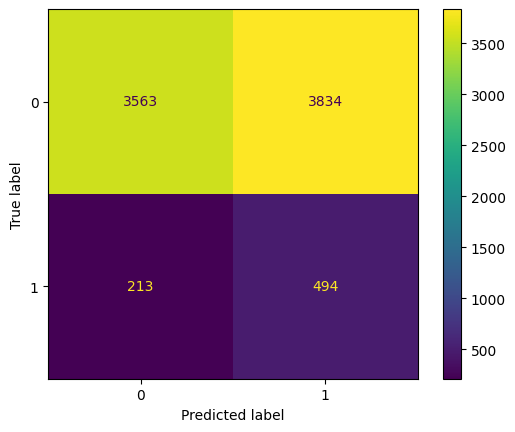

In [72]:
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto);